# 7 · Fine λ sweep (0.9 → 1.0)

Four steps, run top to bottom:

1. **Classify**: is λ = 0.9 still the best value, or does some λ in 0.91–0.99 beat it? (Case A / Case B)
2. **Locate the drop**: do the metrics fall gradually towards λ = 1, or only at exactly λ = 1? Is it caused by zero-gain ties?
3. **Paper outputs**: Table 8 (LaTeX), Fig. 7 with the corrected axis label, a zoom figure for 0.9–1.0, and Fig. 5 with the corrected colour-bar label.
4. **Numbers for the text**: the numbers quoted in §4.4, §5.1 and §5.4, recomputed and checked.

**Inputs:** `Results.perf_greedy_tree_path_all` (our method, all λ), `Results.perf_all` (the 19 ranked configurations), and the greedy selection histories in `CandidateLists.path_greedy_tree`.
**Outputs:** `result_impact_by_lam_fine.csv` and new figures in `figures/`. No existing figure is overwritten.

In [6]:
%load_ext autoreload
%autoreload all

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
import os
import glob

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.ticker import FuncFormatter, MultipleLocator

import src.graph_tokenizer_gd_tree_dev.config as config

os.makedirs("figures", exist_ok=True)

# ---- settings ---------------------------------------------------------------
METRIC_CORE = ["conciseness", "distance_score", "unique_rate", "unknown_rate", "semantic_coverage"]
HIGHER_IS_BETTER = {"semantic_coverage": True, "distance_score": True, "unique_rate": True,
                    "conciseness": False, "unknown_rate": False}
LEVELS = {"High": (500, 6500), "Mid": (7000, 13000), "Low": (13500, 19500)}   # same bins as Table 6
LEVEL_ORDER = ["High", "Mid", "Low"]

DEFAULT_LAM = 0.9
FINE_LAMS = [round(0.9 + 0.01 * i, 2) for i in range(11)]       # 0.90, 0.91, ..., 0.99, 1.00
COARSE_LAMS = [round(0.1 * i, 1) for i in range(1, 11)]         # 0.1, ..., 1.0 (Fig. 7 grid, λ = 0 omitted)

# the 19 configurations ranked in Tables 7 and 12 -- the fine λ values are NOT added to this ranking
ORIGINAL_19 = [f"{0.1 * i:.1f}" for i in range(11)] + [
    "discrete_set_cover", "k_random_all_samples", "highest_degree", "highest_degree_dist_1",
    "most_children", "pagerank", "personalized_pagerank", "closeness_centrality"]

# "practically equal" thresholds for the verdict (absolute difference to λ = 0.9)
TOL = {"semantic_coverage": 0.001, "distance_score": 0.005, "unique_rate": 0.005,
       "unknown_rate": 0.001, "conciseness": 0.1}     # conciseness in tokens per concept

# eval.py names -> paper names (unk_rate = uncovered branch rate, uncovered_rate = unknown rate)
RENAME = {"unk_rate": "uncovered_branche_rate", "unk_branche_rate": "uncovered_branche_rate",
          "uncovered_rate": "unknown_rate"}

LAM_LABEL = "Distance decay $\\lambda$"
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"

In [8]:
def tidy(df):
    # harmonize metric names across the result files
    return df.rename({old: new for old, new in RENAME.items() if old in df.columns})


def add_level(df):
    # compression level of each budget k; 'lvl' is only a sort key (High, Mid, Low)
    level = (pl.when(pl.col("k").is_between(*LEVELS["High"])).then(pl.lit("High"))
               .when(pl.col("k").is_between(*LEVELS["Mid"])).then(pl.lit("Mid"))
               .when(pl.col("k").is_between(*LEVELS["Low"])).then(pl.lit("Low")))
    return (df.with_columns(level.alias("level"))
              .filter(pl.col("level").is_not_null())
              .with_columns(pl.col("level").replace_strict({l: i for i, l in enumerate(LEVEL_ORDER)},
                                                           return_dtype=pl.Int8).alias("lvl")))


def level_means(df, metrics):
    # mean of each metric over the 13 budgets of each compression level (Table 8)
    return (add_level(df)
            .group_by(["lvl", "level", "lam"])
            .agg([pl.col(m).mean() for m in metrics])
            .sort(["lvl", "lam"]))


def rank_configs(df, config_col):
    # Section 4.2: rank configurations at each k on each core metric (ties -> average rank),
    # average the five ranks, then average over the 13 budgets of each level
    return (add_level(df)
            .with_columns([pl.col(m).rank(method="average", descending=HIGHER_IS_BETTER[m])
                             .over("k").alias(f"{m}_rank") for m in METRIC_CORE])
            .with_columns(pl.mean_horizontal([f"{m}_rank" for m in METRIC_CORE]).alias("avg_rank"))
            .group_by(["lvl", "level", config_col])
            .agg([pl.col(f"{m}_rank").mean() for m in METRIC_CORE] + [pl.col("avg_rank").mean()])
            .sort(["lvl", "avg_rank"]))


def lam_str(lam):
    # 0.0, 0.1, 0.95, 1.0 -- one decimal unless two are needed
    return f"{lam:.1f}" if round(lam, 1) == lam else f"{lam:.2f}"

In [9]:
# ---- our method, all λ ---------------------------------------------------------
ours_raw = tidy(pl.read_parquet(config.Results().perf_greedy_tree_path_all))
ours = (ours_raw
        .with_columns(pl.col("file_type").cast(pl.Float64).round(2).alias("lam"))
        .unique(subset=["lam", "k"], keep="last", maintain_order=True)   # in case an eval cell was run twice
        .sort(["lam", "k"]))
EXTRA = [m for m in ["uncovered_branche_rate"] if m in ours.columns]

n_k = len(config.TokenizerParam().Ks)
per_lam = ours.group_by("lam").agg(pl.len().alias("n_budgets")).sort("lam")
print(f"duplicate (λ, k) rows dropped: {ours_raw.height - ours.height}")
print("λ values found:", [lam_str(l) for l in per_lam["lam"].to_list()])
incomplete = per_lam.filter(pl.col("n_budgets") != n_k)
print(f"OK: every λ has all {n_k} budgets" if incomplete.is_empty() else incomplete)

missing = [l for l in FINE_LAMS if l not in per_lam["lam"].to_list()]
assert not missing, f"no results for λ = {missing}: run the 'GREEDY 0.9 - 1' cell of notebook 4 first"

duplicate (λ, k) rows dropped: 0
λ values found: ['0.0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '0.91', '0.92', '0.93', '0.94', '0.95', '0.96', '0.97', '0.98', '0.99', '1.0']
OK: every λ has all 39 budgets


In [10]:
lam_means = level_means(ours, METRIC_CORE + EXTRA)
lam_means.drop("lvl").write_csv("result_impact_by_lam_fine.csv")

with pl.Config(tbl_rows=-1, tbl_cols=-1, float_precision=4):
    display(lam_means.filter(pl.col("lam").is_in(FINE_LAMS)).drop("lvl"))

level,lam,conciseness,distance_score,unique_rate,unknown_rate,semantic_coverage,uncovered_branche_rate
str,f64,f64,f64,f64,f64,f64,f64
"""High""",0.9000,16.3127,0.7689,0.7067,0.0000,0.9999,0.0418
"""High""",0.9100,9.7794,0.7846,0.7065,0.0000,0.9999,0.0413
"""High""",0.9200,9.7754,0.7847,0.7060,0.0000,0.9999,0.0410
"""High""",0.9300,9.7665,0.7849,0.7058,0.0000,0.9999,0.0404
"""High""",0.9400,9.7685,0.7850,0.7050,0.0000,0.9999,0.0397
"""High""",0.9500,9.7708,0.7851,0.7044,0.0000,0.9999,0.0391
"""High""",0.9600,9.7444,0.7853,0.7037,0.0000,1.0000,0.0385
"""High""",0.9700,9.7457,0.7853,0.7037,0.0000,1.0000,0.0377
"""High""",0.9800,9.7424,0.7856,0.7031,0.0000,1.0000,0.0362


## Step 1: Classify (Case A or Case B)

**1a. Difference to λ = 0.9**, signed so that **> 0 always means better than 0.9**. Conciseness is in tokens per concept.
`n_better` / `n_worse` count the core metrics on which a λ beats or loses to 0.9 by more than `TOL`.

In [11]:
ref = (lam_means.filter(pl.col("lam") == DEFAULT_LAM)
       .select(["level"] + [pl.col(m).alias(f"{m}__ref") for m in METRIC_CORE]))

delta = (lam_means.filter(pl.col("lam").is_in(FINE_LAMS))
         .join(ref, on="level")
         .with_columns([((pl.col(m) - pl.col(f"{m}__ref")) * (1 if HIGHER_IS_BETTER[m] else -1)).alias(m)
                        for m in METRIC_CORE])
         .with_columns(
             pl.sum_horizontal([(pl.col(m) > TOL[m]).cast(pl.Int8) for m in METRIC_CORE]).alias("n_better"),
             pl.sum_horizontal([(pl.col(m) < -TOL[m]).cast(pl.Int8) for m in METRIC_CORE]).alias("n_worse"))
         .select(["lvl", "level", "lam"] + METRIC_CORE + ["n_better", "n_worse"])
         .sort(["lvl", "lam"]))

with pl.Config(tbl_rows=-1, tbl_cols=-1, float_precision=4):
    display(delta.drop("lvl"))

level,lam,conciseness,distance_score,unique_rate,unknown_rate,semantic_coverage,n_better,n_worse
str,f64,f64,f64,f64,f64,f64,i8,i8
"""High""",0.9000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0,0
"""High""",0.9100,6.5333,0.0157,-0.0002,0.0000,0.0000,2,0
"""High""",0.9200,6.5374,0.0158,-0.0007,0.0000,0.0000,2,0
"""High""",0.9300,6.5462,0.0160,-0.0009,0.0000,0.0000,2,0
"""High""",0.9400,6.5442,0.0161,-0.0016,0.0000,0.0000,2,0
"""High""",0.9500,6.5420,0.0162,-0.0023,0.0000,0.0000,2,0
"""High""",0.9600,6.5684,0.0164,-0.0029,0.0000,0.0001,2,0
"""High""",0.9700,6.5670,0.0164,-0.0030,0.0000,0.0001,2,0
"""High""",0.9800,6.5703,0.0166,-0.0035,0.0000,0.0001,2,0


**1b. Ranking within the fine grid only** (λ = 0.90 … 1.00), using the same procedure as Section 4.2.

In [12]:
mini_rank = rank_configs(ours.filter(pl.col("lam").is_in(FINE_LAMS)), "lam")

with pl.Config(tbl_rows=-1, tbl_cols=-1, float_precision=2):
    for lvl in LEVEL_ORDER:
        print(f"--- {lvl} compression: top 5 of {len(FINE_LAMS)}")
        display(mini_rank.filter(pl.col("level") == lvl).drop(["lvl", "level"]).head(5))

--- High compression: top 5 of 11


lam,conciseness_rank,distance_score_rank,unique_rate_rank,unknown_rate_rank,semantic_coverage_rank,avg_rank
f64,f64,f64,f64,f64,f64,f64
0.99,1.92,1.85,9.92,5.96,2.00,4.33
0.98,3.08,2.92,8.69,5.96,3.00,4.73
0.97,3.46,3.54,7.35,5.96,4.46,4.95
0.96,3.92,3.69,7.58,5.96,5.69,5.37
0.95,6.08,5.31,6.00,5.96,5.31,5.73


--- Mid compression: top 5 of 11


lam,conciseness_rank,distance_score_rank,unique_rate_rank,unknown_rate_rank,semantic_coverage_rank,avg_rank
f64,f64,f64,f64,f64,f64,f64
0.99,1.15,1.00,3.00,6.00,2.00,2.63
0.98,2.08,2.00,3.00,6.00,3.00,3.22
0.97,2.77,3.00,5.08,6.00,4.46,4.26
0.96,4.08,4.00,5.12,6.00,6.23,5.08
0.95,5.08,5.00,6.00,6.00,4.85,5.38


--- Low compression: top 5 of 11


lam,conciseness_rank,distance_score_rank,unique_rate_rank,unknown_rate_rank,semantic_coverage_rank,avg_rank
f64,f64,f64,f64,f64,f64,f64
0.99,2.15,1.31,3.15,6.00,2.00,2.92
0.98,2.77,2.54,2.15,6.00,3.00,3.29
0.97,2.38,2.46,3.62,6.00,4.00,3.69
0.96,4.38,3.77,3.65,6.00,5.38,4.64
0.95,5.38,5.23,5.81,6.00,6.46,5.78


**1c. Would a fine λ change Table 7?** Each fine λ is added, one at a time, to the 19 ranked configurations (20 in total).
The first output must reproduce Table 7 (λ = 0.9: 4.5 / 4.3 / 4.2).

In [13]:
perf_all = tidy(pl.read_parquet(config.Results().perf_all))
base19 = (perf_all.filter(pl.col("file_type").is_in(ORIGINAL_19))
          .group_by(["file_type", "k"])
          .agg([pl.col(m).mean() for m in METRIC_CORE])          # averages the 20 random draws
          .select(["file_type", "k"] + METRIC_CORE))
assert base19["file_type"].n_unique() == 19, sorted(base19["file_type"].unique().to_list())

rank19 = rank_configs(base19, "file_type")
print("sanity check, λ = 0.9 in the 19-configuration ranking (Table 7: 4.5 / 4.3 / 4.2):")
with pl.Config(float_precision=2):
    display(rank19.filter(pl.col("file_type") == "0.9").select(["level", "avg_rank"]))

rows = []
for lam in [l for l in FINE_LAMS if l not in (DEFAULT_LAM, 1.0)]:
    name = f"{lam:.2f}"
    new = (ours.filter(pl.col("lam") == lam)
               .with_columns(pl.lit(name).alias("file_type"))
               .select(["file_type", "k"] + METRIC_CORE))
    r = rank_configs(pl.concat([base19, new]), "file_type")
    for lvl in LEVEL_ORDER:
        sub = r.filter(pl.col("level") == lvl)
        order = sub["file_type"].to_list()
        rows.append({"level": lvl, "lam": lam,
                     "avg_rank_new": sub.filter(pl.col("file_type") == name)["avg_rank"][0],
                     "avg_rank_0.9": sub.filter(pl.col("file_type") == "0.9")["avg_rank"][0],
                     "position_new": order.index(name) + 1,
                     "position_0.9": order.index("0.9") + 1})
insert_check = pl.DataFrame(rows)

with pl.Config(tbl_rows=-1, float_precision=2):
    display(insert_check)

sanity check, λ = 0.9 in the 19-configuration ranking (Table 7: 4.5 / 4.3 / 4.2):


level,avg_rank
str,f64
"""High""",4.48
"""Mid""",4.30
"""Low""",4.22


level,lam,avg_rank_new,avg_rank_0.9,position_new,position_0.9
str,f64,f64,f64,i64,i64
"""High""",0.91,3.83,5.26,1,2
"""Mid""",0.91,4.09,4.95,1,2
"""Low""",0.91,4.42,4.98,1,2
"""High""",0.92,3.91,5.23,1,2
"""Mid""",0.92,3.92,5.11,1,2
"""Low""",0.92,4.43,4.97,1,2
"""High""",0.93,3.91,5.22,1,2
"""Mid""",0.93,3.97,5.09,1,2
"""Low""",0.93,4.38,5.02,1,2


In [14]:
# ---- verdict ---------------------------------------------------------------------
clearly_better = delta.filter((pl.col("lam") != DEFAULT_LAM) & (pl.col("n_better") > 0) & (pl.col("n_worse") == 0))
beats_in_ranking = insert_check.filter(pl.col("avg_rank_new") < pl.col("avg_rank_0.9"))

for lvl in LEVEL_ORDER:
    sub = mini_rank.filter(pl.col("level") == lvl)
    best = sub.row(0, named=True)
    ref_rank = sub.filter(pl.col("lam") == DEFAULT_LAM)["avg_rank"][0]
    print(f"{lvl:>4}: best λ in 0.90-1.00 = {lam_str(best['lam'])} (avg rank {best['avg_rank']:.2f}; λ = 0.9: {ref_rank:.2f})")

print()
if clearly_better.is_empty() and beats_in_ranking.is_empty():
    print("CASE A: no λ in 0.91-0.99 beats 0.9 beyond TOL, and none outranks it among the 19 configurations.")
    print("        -> keep λ = 0.9; Tables 7/12, Fig. 5 and the HERO results stay as they are.")
else:
    print("CASE B: some λ in 0.91-0.99 is better than 0.9:")
    if not clearly_better.is_empty():
        print("  better beyond TOL on >= 1 core metric and worse on none:")
        display(clearly_better.drop("lvl"))
    if not beats_in_ranking.is_empty():
        print("  outranks λ = 0.9 when added to the 19 configurations:")
        display(beats_in_ranking)
    print("  -> recommended: keep 0.9 as the default and report the best value in §4.4 (no rerun).")

High: best λ in 0.90-1.00 = 0.99 (avg rank 4.33; λ = 0.9: 7.95)
 Mid: best λ in 0.90-1.00 = 0.99 (avg rank 2.63; λ = 0.9: 8.55)
 Low: best λ in 0.90-1.00 = 0.99 (avg rank 2.92; λ = 0.9: 8.64)

CASE B: some λ in 0.91-0.99 is better than 0.9:
  better beyond TOL on >= 1 core metric and worse on none:


level,lam,conciseness,distance_score,unique_rate,unknown_rate,semantic_coverage,n_better,n_worse
str,f64,f64,f64,f64,f64,f64,i8,i8
"""High""",0.91,6.533289,0.015733,-0.000218,0.000002,0.00002,2,0
"""High""",0.92,6.537365,0.015826,-0.000722,0.000002,0.000031,2,0
"""High""",0.93,6.546222,0.015985,-0.000882,0.000002,0.000036,2,0
"""High""",0.94,6.5442,0.016079,-0.001648,0.000002,0.000041,2,0
"""High""",0.95,6.54197,0.016203,-0.002317,0.000002,0.000049,2,0
…,…,…,…,…,…,…,…,…
"""Low""",0.95,0.372371,0.002174,0.000237,-0.0,5.3617e-7,1,0
"""Low""",0.96,0.376626,0.002309,0.000745,-0.0,5.3243e-7,1,0
"""Low""",0.97,0.380725,0.002406,0.000642,-0.0,6.0971e-7,1,0


  outranks λ = 0.9 when added to the 19 configurations:


level,lam,avg_rank_new,avg_rank_0.9,position_new,position_0.9
str,f64,f64,f64,i64,i64
"""High""",0.91,3.830769,5.261538,1,2
"""Mid""",0.91,4.092308,4.953846,1,2
"""Low""",0.91,4.423077,4.976923,1,2
"""High""",0.92,3.907692,5.230769,1,2
"""Mid""",0.92,3.923077,5.107692,1,2
…,…,…,…,…,…
"""Mid""",0.98,3.784615,5.153846,1,2
"""Low""",0.98,4.276923,5.123077,1,2
"""High""",0.99,3.953846,5.184615,1,2


  -> recommended: keep 0.9 as the default and report the best value in §4.4 (no rerun).


## Step 2: Where does the drop happen?

**2a. Plateau or cliff?** This compares the largest change vs 0.9 anywhere in 0.91–0.99 with the change at λ = 1 (signed, > 0 = better).

In [15]:
plateau = (delta.filter(pl.col("lam").is_between(0.91, 0.99))
           .group_by(["lvl", "level"])
           .agg([pl.col(m).abs().max() for m in METRIC_CORE])
           .sort("lvl"))
at_one = delta.filter(pl.col("lam") == 1.0).select(["level"] + METRIC_CORE)

with pl.Config(tbl_cols=-1, float_precision=4):
    print("largest |change vs 0.9| within 0.91-0.99:")
    display(plateau.drop("lvl"))
    print("change vs 0.9 at λ = 1:")
    display(at_one)

largest |change vs 0.9| within 0.91-0.99:


level,conciseness,distance_score,unique_rate,unknown_rate,semantic_coverage
str,f64,f64,f64,f64,f64
"""High""",6.5989,0.0169,0.0048,0.0000,0.0001
"""Mid""",1.1110,0.0059,0.0008,0.0000,0.0000
"""Low""",0.3814,0.0025,0.0012,0.0000,0.0000


change vs 0.9 at λ = 1:


level,conciseness,distance_score,unique_rate,unknown_rate,semantic_coverage
str,f64,f64,f64,f64,f64
"""High""",-0.9550,-0.1070,-0.2385,0.0000,0.0001
"""Mid""",-4.3588,-0.1371,-0.2863,-0.0000,0.0000
"""Low""",-3.7023,-0.1343,-0.2737,-0.0000,0.0000


**2b. Zero-gain ties.** At λ = 1, once every walk from a mapped concept reaches some token, no candidate can raise the coverage any more.
All remaining candidates then have marginal gain 0, and the heap breaks the ties on the token id, which is essentially arbitrary.
At λ < 1, a closer token still has a positive gain (λ^j > λ^J), so the ties never occur.

In [16]:
hist_files = {}
for f in glob.glob(os.path.join(config.CandidateLists().path_greedy_tree, "*.parquet")):
    try:
        hist_files[round(float(os.path.splitext(os.path.basename(f))[0]), 2)] = f
    except ValueError:
        pass

HIST_LAMS = [l for l in [0.9, 0.95, 0.99, 1.0] if l in hist_files]
K_MAX = int(max(config.TokenizerParam().Ks))
CHECK_K = [500, 6500, 13000, 19500]
EPS = 1e-12

hist = {}
for lam in HIST_LAMS:
    h = pl.read_parquet(hist_files[lam])
    hist[lam] = (h.sort("index") if "index" in h.columns else h).head(K_MAX)   # selection order

rows = []
for lam, h in hist.items():
    g = h["gain"].to_numpy()
    zero = g <= EPS
    row = {"lam": lam_str(lam),
           "first_zero_gain_rank": int(np.argmax(zero)) + 1 if zero.any() else None}
    for k in CHECK_K:
        row[f"zero_share@{k}"] = float(zero[:k].mean())
    for k in CHECK_K:
        row[f"gain@{k}"] = float(g[k - 1])
    rows.append(row)
gain_summary = pl.DataFrame(rows)

share_cols = ["lam", "first_zero_gain_rank"] + [f"zero_share@{k}" for k in CHECK_K]
with pl.Config(tbl_cols=-1, tbl_width_chars=200, float_precision=3):
    display(gain_summary.select(share_cols))
with pl.Config(tbl_cols=-1, tbl_width_chars=200, fmt_float="mixed"):
    display(gain_summary.select(["lam"] + [f"gain@{k}" for k in CHECK_K]))

if 1.0 in hist:
    z = hist[1.0].filter(pl.col("gain") <= EPS)
    ids = z["token"].to_list()
    if len(ids) > 1:
        asc = np.mean([a < b for a, b in zip(ids[:-1], ids[1:])])
        print(f"λ = 1: {len(ids):,} of the first {K_MAX:,} tokens were selected with zero marginal gain; "
              f"{asc:.1%} of consecutive zero-gain picks are in ascending token-id order.")
        display(z.select([c for c in ["index", "token", "label", "gain"] if c in z.columns]).head(10))
    else:
        print("λ = 1: no zero-gain picks within the evaluated budgets -- the tie explanation does not apply.")

lam,first_zero_gain_rank,zero_share@500,zero_share@6500,zero_share@13000,zero_share@19500
str,i64,f64,f64,f64,f64
"""0.9""",null,0.000,0.000,0.000,0.000
"""0.95""",null,0.000,0.000,0.000,0.000
"""0.99""",null,0.000,0.000,0.000,0.000
"""1.0""",944,0.000,0.855,0.927,0.952


lam,gain@500,gain@6500,gain@13000,gain@19500
str,f64,f64,f64,f64
"""0.9""",0.000088,0.000005,0.000004,0.000003
"""0.95""",0.000052,0.000003,0.000002,0.000001
"""0.99""",0.000012,5.7083e-7,3.6724e-7,2.9156e-7
"""1.0""",3.8190e-8,2.4057e-21,2.4057e-21,2.4057e-23


λ = 1: 18,557 of the first 19,500 tokens were selected with zero marginal gain; 91.1% of consecutive zero-gain picks are in ascending token-id order.


index,token,label,gain
u32,str,str,f64
943,"""441903006""","""Specimen obtained by bronchial…",3.0095e-19
944,"""168139001+472868006""","""168139001|Peritoneal fluid spe…",2.4121e-19
945,"""472884007""","""Swab from deep wound (specimen…",1.9057e-19
946,"""258520000""","""Vaginal swab (specimen)""",1.8235e-19
947,"""258411007""","""Nasopharyngeal aspirate (speci…",1.6912e-19
948,"""10200004""","""Liver structure (body structur…",1.5898e-19
949,"""472882006""","""Swab from superficial wound (s…",1.5457e-19
950,"""445297001""","""Swab of internal nose (specime…",1.4875e-19
951,"""258502009""","""Pus swab (specimen)""",1.4811e-19


In [17]:
# overlap (Jaccard) of the selected token sets at the same budget
PAIRS = [(0.9, 0.95), (0.9, 0.99), (0.99, 1.0), (0.9, 1.0)]
rows = []
for a, b in PAIRS:
    if a in hist and b in hist:
        ta, tb = hist[a]["token"].to_list(), hist[b]["token"].to_list()
        row = {"pair": f"{lam_str(a)} vs {lam_str(b)}"}
        for k in CHECK_K:
            A, B = set(ta[:k]), set(tb[:k])
            row[f"k={k}"] = len(A & B) / len(A | B)
        rows.append(row)

with pl.Config(float_precision=3):
    display(pl.DataFrame(rows))

pair,k=500,k=6500,k=13000,k=19500
str,f64,f64,f64,f64
"""0.9 vs 0.95""",0.887,0.945,0.948,0.952
"""0.9 vs 0.99""",0.779,0.906,0.915,0.920
"""0.99 vs 1.0""",0.264,0.134,0.142,0.199
"""0.9 vs 1.0""",0.206,0.134,0.142,0.199


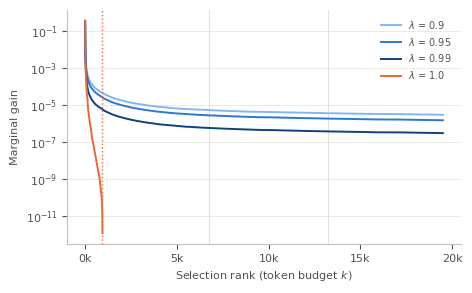

In [18]:
# marginal gain along the selection (log scale); zero gains cannot be drawn, so a dotted line marks where they start
HIST_COLOR = {0.9: "#86b6ef", 0.95: "#2a78d6", 0.99: "#104281", 1.0: "#eb6834"}

plt.rcParams.update({"font.size": 8, "axes.edgecolor": "#c3c2b7", "xtick.color": INK2, "ytick.color": INK2})
fig, ax = plt.subplots(figsize=(4.6, 2.8), constrained_layout=True)
for x in [6750, 13250]:                                  # compression-level boundaries
    ax.axvline(x, color=GRID, lw=0.8, zorder=0)
for lam, h in hist.items():
    g = h["gain"].to_numpy()
    r = np.arange(1, len(g) + 1)
    pos = g > EPS
    ax.plot(r[pos], g[pos], color=HIST_COLOR.get(lam, MUTED), lw=1.4, label=f"$\\lambda$ = {lam_str(lam)}")
    if (~pos).any():
        ax.axvline(int(np.argmax(~pos)) + 1, color=HIST_COLOR.get(lam, MUTED), lw=1.0, ls=":")
ax.set_yscale("log")
ax.set_xlabel("Selection rank (token budget $k$)", color=INK2)
ax.set_ylabel("Marginal gain", color=INK2)
ax.xaxis.set_major_locator(MultipleLocator(5000))
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
ax.grid(axis="y", color=GRID, lw=0.5)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.legend(frameon=False, fontsize=7, labelcolor=INK2)
fig.savefig("figures/gain_vs_rank_lambda.png", dpi=400, bbox_inches="tight")

## Step 3: Paper outputs

**3a. Table 8**: copy the LaTeX into your table. Edit `TABLE_LAMS` to choose the rows.

In [19]:
TABLE_LAMS = [0.0, 0.1, 0.4, 0.6, 0.9, 0.95, 0.99, 1.0]
COLS = ["semantic_coverage", "distance_score", "unique_rate", "unknown_rate", "conciseness"]
FMT = {"semantic_coverage": "{:.3f}", "distance_score": "{:.3f}", "unique_rate": "{:.3f}",
       "unknown_rate": "{:.3f}", "conciseness": "{:.1f}"}

lines = [r"\begin{tabular}{llrrrrr}", r"\toprule",
         r"Compression level & $\lambda$ & Cov.$\uparrow$ & Dist.$\uparrow$ & Uniq.$\uparrow$ & Unk.$\downarrow$ & Conc.$\downarrow$ \\",
         r"\midrule"]
for i, lvl in enumerate(LEVEL_ORDER):
    sub = lam_means.filter((pl.col("level") == lvl) & pl.col("lam").is_in(TABLE_LAMS)).sort("lam")
    for j, row in enumerate(sub.iter_rows(named=True)):
        first = rf"\multirow{{{sub.height}}}{{*}}{{{lvl}}}" if j == 0 else ""
        vals = " & ".join(FMT[m].format(row[m]) for m in COLS)
        lines.append(f"{first} & {lam_str(row['lam'])} & {vals} \\\\")
    lines.append(r"\midrule" if i < len(LEVEL_ORDER) - 1 else r"\bottomrule")
lines.append(r"\end{tabular}")
print("\n".join(lines))

\begin{tabular}{llrrrrr}
\toprule
Compression level & $\lambda$ & Cov.$\uparrow$ & Dist.$\uparrow$ & Uniq.$\uparrow$ & Unk.$\downarrow$ & Conc.$\downarrow$ \\
\midrule
\multirow{8}{*}{High} & 0.0 & 0.086 & 0.093 & 0.143 & 0.765 & 0.9 \\
 & 0.1 & 0.978 & 0.667 & 0.617 & 0.002 & 18.8 \\
 & 0.4 & 0.997 & 0.739 & 0.714 & 0.001 & 18.4 \\
 & 0.6 & 0.999 & 0.757 & 0.716 & 0.000 & 17.4 \\
 & 0.9 & 1.000 & 0.769 & 0.707 & 0.000 & 16.3 \\
 & 0.95 & 1.000 & 0.785 & 0.704 & 0.000 & 9.8 \\
 & 0.99 & 1.000 & 0.786 & 0.702 & 0.000 & 9.7 \\
 & 1.0 & 1.000 & 0.662 & 0.468 & 0.000 & 17.3 \\
\midrule
\multirow{8}{*}{Mid} & 0.0 & 0.238 & 0.250 & 0.298 & 0.493 & 2.0 \\
 & 0.1 & 0.990 & 0.767 & 0.731 & 0.000 & 11.1 \\
 & 0.4 & 0.999 & 0.837 & 0.839 & 0.000 & 9.1 \\
 & 0.6 & 1.000 & 0.854 & 0.850 & 0.000 & 8.1 \\
 & 0.9 & 1.000 & 0.865 & 0.856 & 0.000 & 7.1 \\
 & 0.95 & 1.000 & 0.870 & 0.856 & 0.000 & 6.0 \\
 & 0.99 & 1.000 & 0.871 & 0.857 & 0.000 & 6.0 \\
 & 1.0 & 1.000 & 0.728 & 0.570 & 0.000 & 11.5 \\
\mi

**3b. Figures for λ.** Fig. 7 is redrawn with the axis label "Distance decay λ". The zoom figure shows 0.90–1.00 and could go in the appendix.
Levels are told apart by colour only (no marker styles).

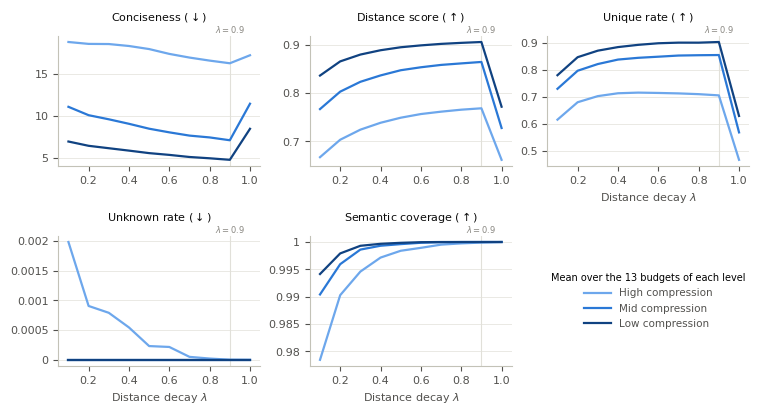

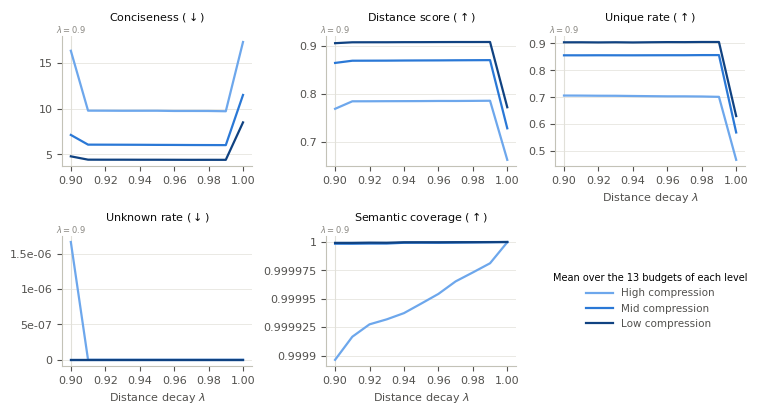

In [20]:
METRIC_TITLE = {
    "semantic_coverage": "Semantic coverage ($\\uparrow$)",
    "distance_score":    "Distance score ($\\uparrow$)",
    "unique_rate":       "Unique rate ($\\uparrow$)",
    "unknown_rate":      "Unknown rate ($\\downarrow$)",
    "conciseness":       "Conciseness ($\\downarrow$)",
}
LEVEL_COLOR = {"High": "#6da7ec", "Mid": "#2a78d6", "Low": "#104281"}


def plot_metrics_vs_lambda(df_lam, metrics, xlim, major, ncols=3, panel_size=(2.5, 2), fname=None):
    # df_lam: output of level_means (one row per level x λ)
    plt.rcParams.update({"font.size": 8, "axes.edgecolor": "#c3c2b7", "xtick.color": INK2, "ytick.color": INK2})
    n_panels = len(metrics) + 1                              # +1 slot for the legend
    nrows = -(-n_panels // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(panel_size[0] * ncols, panel_size[1] * nrows),
                             sharex=True, constrained_layout=True)
    axes = axes.flatten()
    for ax, metric in zip(axes, metrics):
        ax.axvline(DEFAULT_LAM, color=GRID, lw=0.8, zorder=0)
        ax.text(DEFAULT_LAM, 1.01, f"$\\lambda{{=}}{DEFAULT_LAM}$", transform=ax.get_xaxis_transform(),
                ha="center", va="bottom", fontsize=6, color=MUTED)
        for lvl in LEVEL_ORDER:
            sub = df_lam.filter(pl.col("level") == lvl).sort("lam")
            ax.plot(sub["lam"], sub[metric], color=LEVEL_COLOR[lvl], lw=1.6, label=f"{lvl} compression")
        ax.set_title(METRIC_TITLE.get(metric, metric), fontsize=8, color=INK, pad=11)
        ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))   # no '1e-5' offset text
        ax.grid(axis="y", color=GRID, lw=0.5)
        ax.set_axisbelow(True)
        for s in ("top", "right"):
            ax.spines[s].set_visible(False)
    for ax in axes[len(metrics):]:
        ax.axis("off")
    for ax in axes[:len(metrics)]:
        ax.xaxis.set_major_locator(MultipleLocator(major))
        ax.set_xlim(*xlim)
        ax.tick_params(labelbottom=True)
    for col in range(ncols):                                # x-label on the lowest panel of each column
        idx = list(range(col, len(metrics), ncols))
        if idx:
            axes[idx[-1]].set_xlabel(LAM_LABEL, color=INK2)
    handles, labels = axes[0].get_legend_handles_labels()
    axes[len(metrics)].legend(handles, labels, loc="center", frameon=False, fontsize=7.5, labelcolor=INK2,
                              title="Mean over the 13 budgets of each level", title_fontsize=7, handlelength=2.6)
    if fname:
        fig.savefig(fname, bbox_inches="tight", dpi=400)
    return fig


# Fig. 7: same λ grid as before (0.1 ... 1.0), corrected label
plot_metrics_vs_lambda(lam_means.filter(pl.col("lam").is_in(COARSE_LAMS)), METRIC_CORE,
                       xlim=(0.05, 1.05), major=0.2, fname="figures/metrics_vs_lambda_no0_v2.png")

# zoom: 0.90 ... 1.00
plot_metrics_vs_lambda(lam_means.filter(pl.col("lam").is_in(FINE_LAMS)), METRIC_CORE,
                       xlim=(0.895, 1.005), major=0.02, fname="figures/metrics_vs_lambda_zoom.png");

**3c. Fig. 5**: same ranking as before (19 configurations, fine λ values not included), with the colour bar relabelled "Distance decay λ".

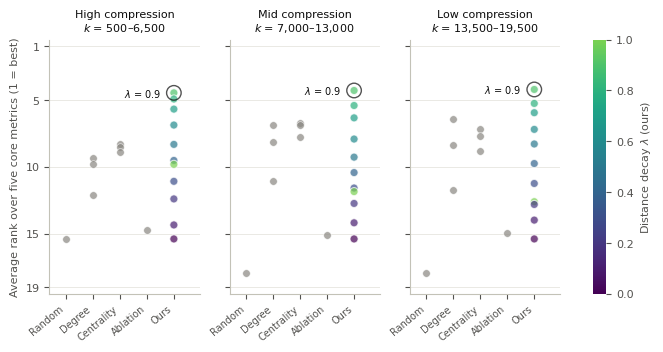

In [21]:
BASELINE_FAMILY = {"closeness_centrality": "centrality-based", "pagerank": "centrality-based",
                   "personalized_pagerank": "centrality-based", "highest_degree": "degree-based",
                   "highest_degree_dist_1": "degree-based", "most_children": "degree-based",
                   "discrete_set_cover": "ours(ablation)", "k_random_all_samples": "random"}
rank_df = rank19.with_columns(
    pl.col("file_type").replace_strict(BASELINE_FAMILY, default="ours").alias("family"))

LEVEL_TITLES = [("High", "High compression\n$k$ = 500–6,500"),
                ("Mid",  "Mid compression\n$k$ = 7,000–13,000"),
                ("Low",  "Low compression\n$k$ = 13,500–19,500")]
FAMILIES = [("random", "Random"), ("degree-based", "Degree"), ("centrality-based", "Centrality"),
            ("ours(ablation)", "Ablation"), ("ours", "Ours")]
lam_cmap = LinearSegmentedColormap.from_list("lam_viridis", plt.cm.viridis(np.linspace(0.0, 0.8, 256)))
lam_norm = Normalize(0.0, 1.0)

plt.rcParams.update({"font.size": 8, "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK2,
                     "xtick.color": INK2, "ytick.color": INK2})
fig, axes = plt.subplots(1, 3, figsize=(7.2, 3.3), sharey=True)
x_pos = {fam: i for i, (fam, _) in enumerate(FAMILIES)}
for ax, (lvl, title) in zip(axes, LEVEL_TITLES):
    d = rank_df.filter(pl.col("level") == lvl)
    for fam, _ in FAMILIES[:-1]:                              # baselines: gray, one column per family
        sub = d.filter(pl.col("family") == fam)
        ax.scatter(np.full(sub.height, x_pos[fam]), sub["avg_rank"], s=30, color=MUTED,
                   edgecolor="white", linewidth=0.5, zorder=3, alpha=0.7)
    ours_pts = d.filter(pl.col("family") == "ours").with_columns(pl.col("file_type").cast(pl.Float64).alias("lam"))
    ax.scatter(np.full(ours_pts.height, x_pos["ours"]), ours_pts["avg_rank"], s=34, c=ours_pts["lam"],
               cmap=lam_cmap, norm=lam_norm, edgecolor="white", linewidth=0.8, zorder=4, alpha=0.7)
    best = ours_pts.sort("avg_rank").row(0, named=True)
    ax.scatter([x_pos["ours"]], [best["avg_rank"]], s=110, facecolor="none", edgecolor=INK,
               linewidth=1.0, zorder=5, alpha=0.7)
    ax.annotate(f"$\\lambda$ = {best['lam']:.1f}", (x_pos["ours"], best["avg_rank"]), xytext=(-9, 0),
                textcoords="offset points", ha="right", va="center", fontsize=7, color=INK)
    ax.set_title(title, fontsize=8, color=INK)
    ax.set_xticks(range(len(FAMILIES)))
    ax.set_xticklabels([lab for _, lab in FAMILIES], rotation=40, ha="right", fontsize=7)
    ax.set_xlim(-0.6, len(FAMILIES) - 0.05)
    ax.grid(axis="y", color=GRID, lw=0.5)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
axes[0].set_ylim(19.5, 0.5)                                   # rank 1 on top
axes[0].set_yticks([1, 5, 10, 15, 19])
axes[0].set_ylabel("Average rank over five core metrics (1 = best)")
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=lam_cmap, norm=lam_norm), ax=axes, fraction=0.025, pad=0.06)
cbar.set_label(LAM_LABEL + " (ours)", color=INK2)
cbar.outline.set_visible(False)
fig.savefig("figures/rank_by_family_v2.png", dpi=400, bbox_inches="tight")

## Step 4: Numbers for the text

Each line gives the section, the value and a check against the number currently in the draft (✓ = still true).

In [22]:
def val(lvl, lam, m):
    return lam_means.filter((pl.col("level") == lvl) & (pl.col("lam") == lam))[m][0]

ok = lambda cond: "✓" if cond else "✗ update the text"

# §4.4: λ = 1 vs 0.9 at mid compression
print("§4.4  λ = 1 vs 0.9 (mid):"
      f" distance {val('Mid', 0.9, 'distance_score'):.3f} -> {val('Mid', 1.0, 'distance_score'):.3f},"
      f" unique {val('Mid', 0.9, 'unique_rate'):.3f} -> {val('Mid', 1.0, 'unique_rate'):.3f},"
      f" conciseness {val('Mid', 0.9, 'conciseness'):.1f} -> {val('Mid', 1.0, 'conciseness'):.1f}")
print(f"§4.4  λ = 0, high compression: unknown rate {val('High', 0.0, 'unknown_rate'):.3f}")

# §4.4 (new paragraph): plateau up to 0.99, drop at 1
for m in METRIC_CORE:
    p = plateau[m].max()
    d1 = at_one[m].to_list()
    print(f"§4.4  {m:<18} max |Δ vs 0.9| in 0.91-0.99 = {p:.4f};  Δ at λ = 1 (High/Mid/Low) = "
          + " / ".join(f"{x:+.4f}" for x in d1))

# §5.4 (block 8): between λ = 0.6 and 0.9
du = max(abs(val(l, 0.9, "unique_rate") - val(l, 0.6, "unique_rate")) for l in LEVEL_ORDER)
dd = max(abs(val(l, 0.9, "distance_score") - val(l, 0.6, "distance_score")) for l in LEVEL_ORDER)
dc = [100 * (val(l, 0.6, "conciseness") - val(l, 0.9, "conciseness")) / val(l, 0.6, "conciseness") for l in LEVEL_ORDER]
dk = val("Low", 0.9, "distance_score") - val("High", 0.9, "distance_score")
print(f"§5.4  0.6 -> 0.9: max |Δ unique| = {du:.4f}  (draft: < 0.01)  {ok(du < 0.01)}")
print(f"§5.4  0.6 -> 0.9: max |Δ distance| = {dd:.4f}  (draft: at most 0.012)  {ok(round(dd, 3) <= 0.012)}")
print(f"§5.4  0.6 -> 0.9: conciseness -{min(dc):.0f}% to -{max(dc):.0f}%  (draft: 6 to 12%)  "
      f"{ok(round(min(dc)) >= 6 and round(max(dc)) <= 12)}")
print(f"§5.4  λ = 0.9, high -> low compression: distance +{dk:.2f}  (draft: 0.14)  {ok(round(dk, 2) == 0.14)}")

# §5.1: zero-gain ties at λ = 1
if 1.0 in hist:
    r = gain_summary.filter(pl.col("lam") == "1.0").row(0, named=True)
    print(f"§5.1  λ = 1: first zero-gain token at rank {r['first_zero_gain_rank']}; zero-gain share of the "
          f"vocabulary at k = 500 / 6,500 / 19,500: {r['zero_share@500']:.0%} / {r['zero_share@6500']:.0%} / "
          f"{r['zero_share@19500']:.0%}")

§4.4  λ = 1 vs 0.9 (mid): distance 0.865 -> 0.728, unique 0.856 -> 0.570, conciseness 7.1 -> 11.5
§4.4  λ = 0, high compression: unknown rate 0.765
§4.4  conciseness        max |Δ vs 0.9| in 0.91-0.99 = 6.5989;  Δ at λ = 1 (High/Mid/Low) = -0.9550 / -4.3588 / -3.7023
§4.4  distance_score     max |Δ vs 0.9| in 0.91-0.99 = 0.0169;  Δ at λ = 1 (High/Mid/Low) = -0.1070 / -0.1371 / -0.1343
§4.4  unique_rate        max |Δ vs 0.9| in 0.91-0.99 = 0.0048;  Δ at λ = 1 (High/Mid/Low) = -0.2385 / -0.2863 / -0.2737
§4.4  unknown_rate       max |Δ vs 0.9| in 0.91-0.99 = 0.0000;  Δ at λ = 1 (High/Mid/Low) = +0.0000 / -0.0000 / -0.0000
§4.4  semantic_coverage  max |Δ vs 0.9| in 0.91-0.99 = 0.0001;  Δ at λ = 1 (High/Mid/Low) = +0.0001 / +0.0000 / +0.0000
§5.4  0.6 -> 0.9: max |Δ unique| = 0.0090  (draft: < 0.01)  ✓
§5.4  0.6 -> 0.9: max |Δ distance| = 0.0119  (draft: at most 0.012)  ✓
§5.4  0.6 -> 0.9: conciseness -6% to -12%  (draft: 6 to 12%)  ✓
§5.4  λ = 0.9, high -> low compression: distance +0.14 